<a href="https://colab.research.google.com/github/Afnankh00/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prediction of Product Sales**


*   Author : Afnan Adel khattab



# **Project Overview**

Clean and prepare the sales prediction dataset for machine learning analysis by addressing data quality issues including missing values, inconsistent categories, and data type validation.


# **Load and Inspect Data**

In [ ]:
# Import required packages
import pandas as pd
import numpy as np
import missingno as msno
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
# Load the sales prediction dataset
# Update this path to match your file location
fpath = '/content/drive/MyDrive/Course 1/Week 1/sales_predictions_2023.csv'
df = pd.read_csv(fpath)

In [ ]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


# **Exploratory Data Analysis**

In [ ]:
# Preview the data
print("First 5 rows:")
df.head()

First 5 rows:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
print("\nLast 5 rows:")
df.tail()


Last 5 rows:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [ ]:
# data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
print(df.isnull().sum())

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [ ]:
# For categorical column like Outlet_Size:
print("Unique values in Outlet_Size (including NaN):")
print(df['Outlet_Size'].unique())

# See value counts INCLUDING missing values:
print("\nValue counts with NaN:")
print(df['Outlet_Size'].value_counts(dropna=False))

Unique values in Outlet_Size (including NaN):
['Medium' nan 'High' 'Small']

Value counts with NaN:
Outlet_Size
Medium    2793
NaN       2410
Small     2388
High       932
Name: count, dtype: int64


# **Feature Inspection**

In [ ]:
print("1) DATASET SIZE")
print("*" * 50)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"DataFrame shape: {df.shape}")
print("*" * 50)
# print the data types
print("2) DATA TYPES")
print("*" * 50)
print(df.dtypes)
# check the no. duplicates rows
print("*" * 50)
print("3) DUPLICATE CHECK")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

1) DATASET SIZE
**************************************************
Number of rows: 8523
Number of columns: 12
DataFrame shape: (8523, 12)
**************************************************
2) DATA TYPES
**************************************************
Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object
**************************************************
3) DUPLICATE CHECK
Number of duplicate rows: 0


In [ ]:
print("\nPercentage of missing values per column:")
missing_pct = round((df.isnull().sum() / len(df)) * 100, 2)
print(missing_pct[missing_pct > 0])


Percentage of missing values per column:
Item_Weight    17.17
Outlet_Size    28.28
dtype: float64


# **Data Cleaning**
# Visualize the Data

<Axes: >

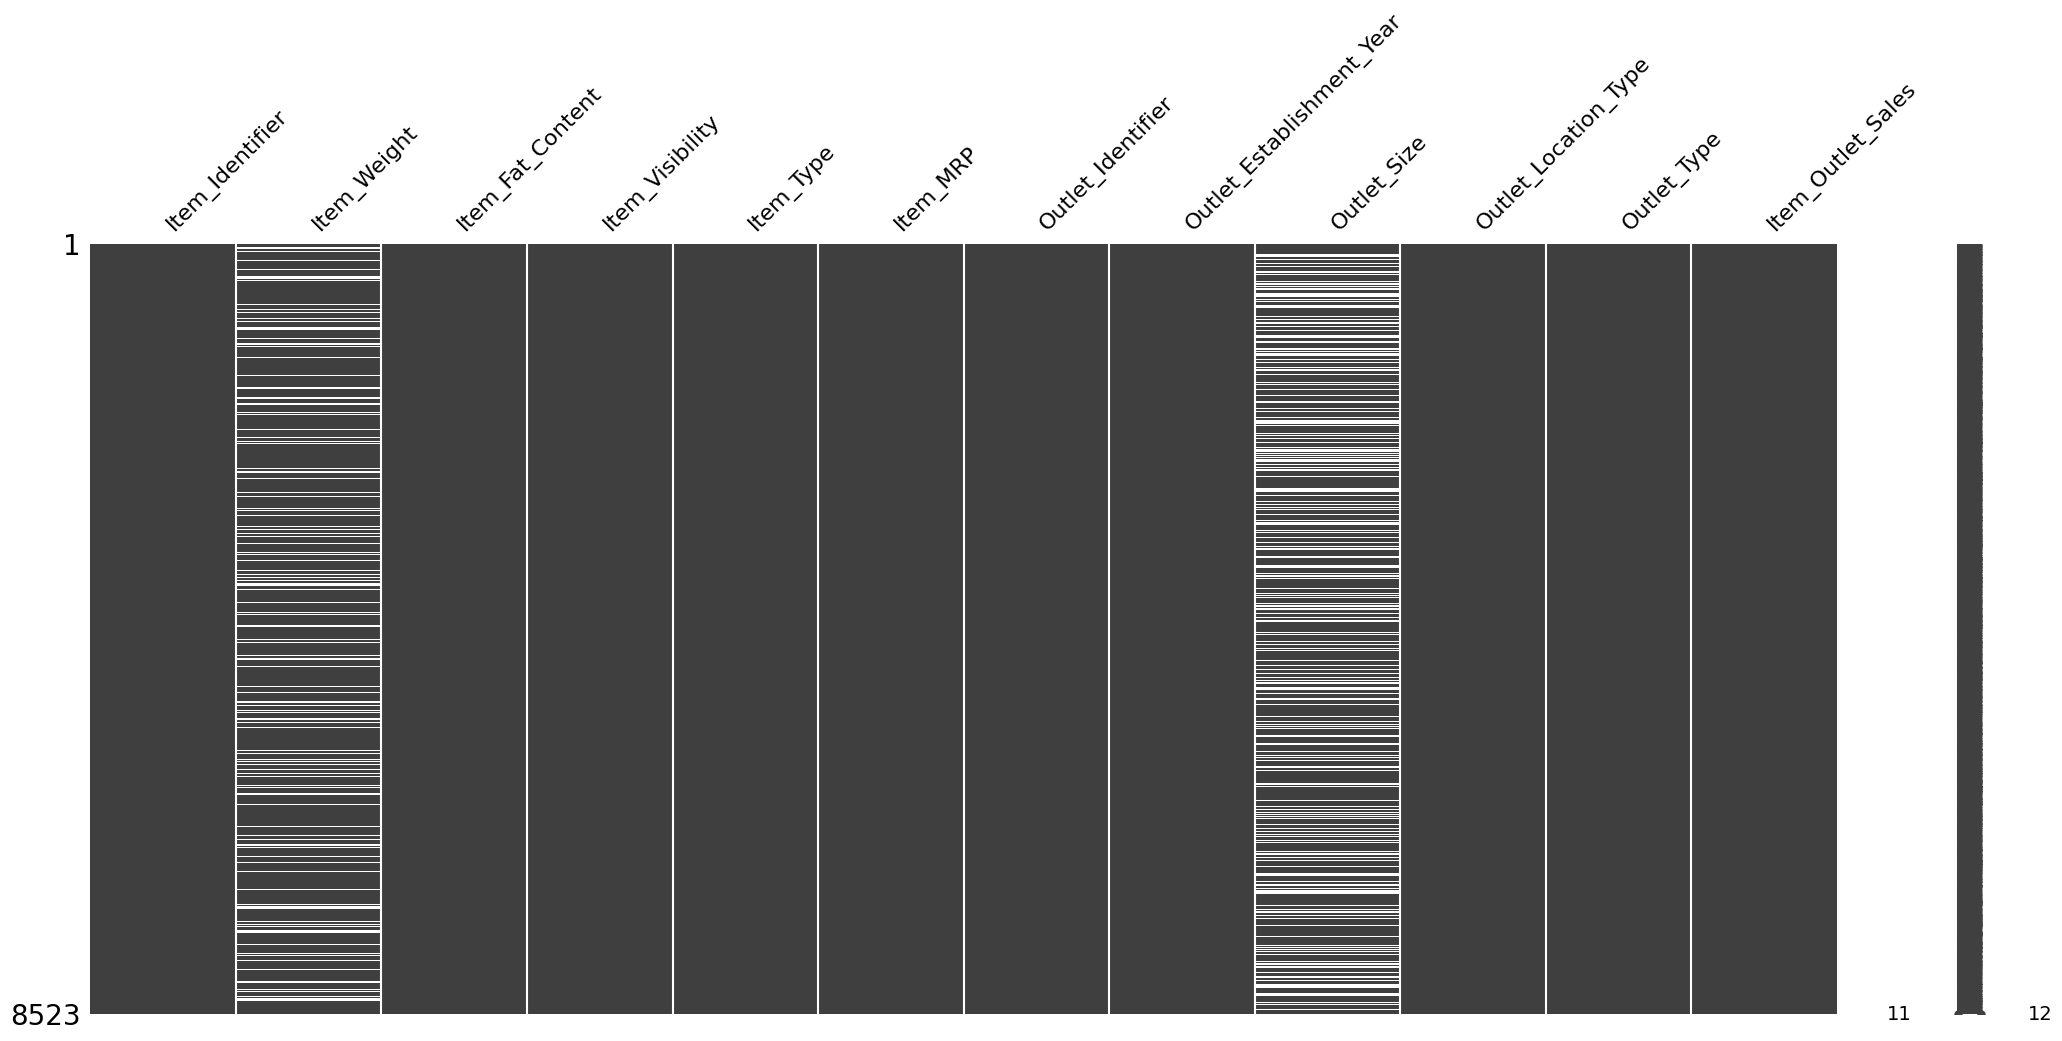

In [ ]:
msno.matrix(df)

In [ ]:
# Get lists of categorical and numeric columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nCategorical columns: {cat_cols}")
print(f"Numeric columns: {num_cols}")


Categorical columns: ['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
Numeric columns: ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']


In [ ]:
# Fill categorical columns with 'MISSING'
df[cat_cols] = df[cat_cols].fillna('MISSING')
print("\nFilled categorical columns with 'MISSING'")

# Fill numeric columns with -1
df[num_cols] = df[num_cols].fillna(-1)
print("Filled numeric columns with -1")


Filled categorical columns with 'MISSING'
Filled numeric columns with -1


In [ ]:
print("\nMissing values after addressing:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Missing values after addressing:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

Total missing values: 0


<Axes: >

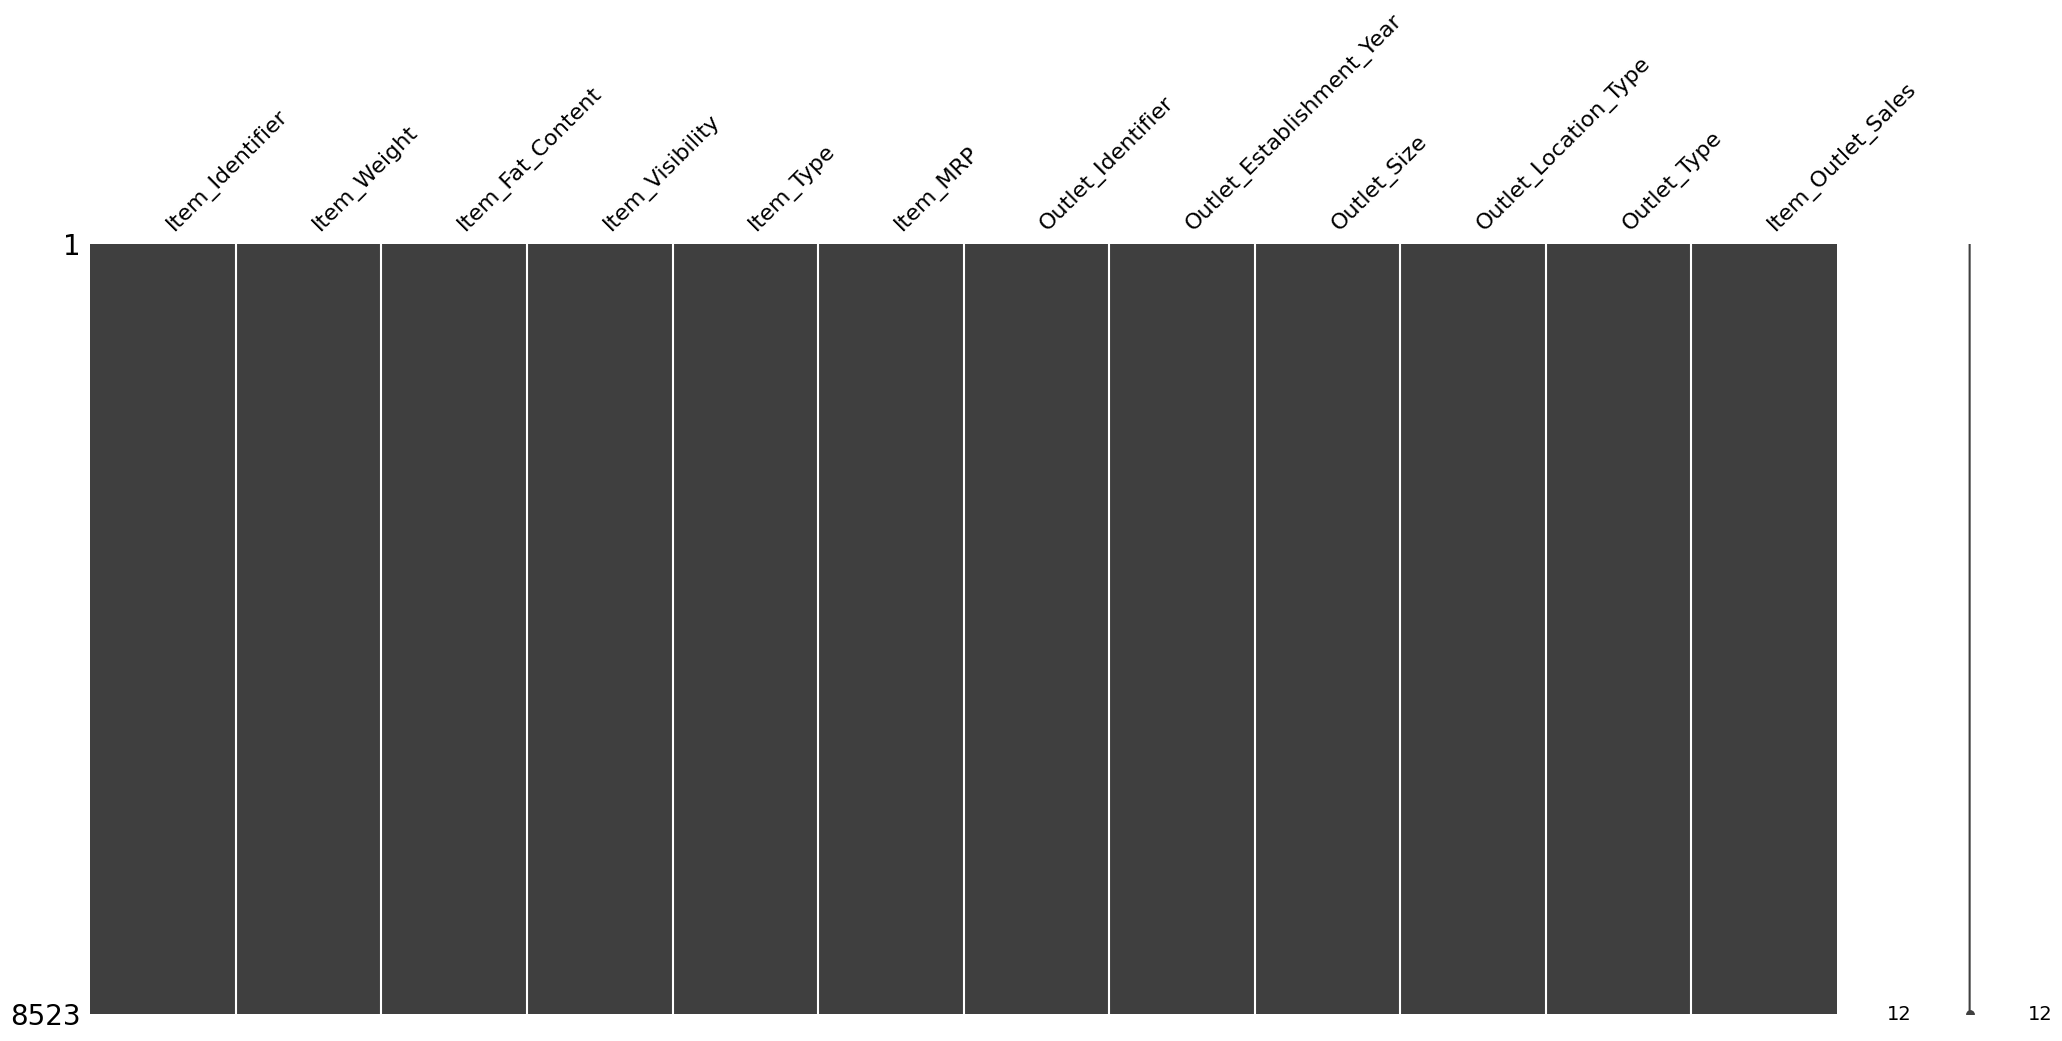

In [ ]:
# Confirm with missingno
msno.matrix(df)

In [ ]:
print("\nValue counts BEFORE fixing inconsistencies:")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 50)



Value counts BEFORE fixing inconsistencies:

Item_Identifier:
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64
--------------------------------------------------

Item_Fat_Content:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
--------------------------------------------------

Item_Type:
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Nam

In [ ]:
# Fix Item_Fat_Content inconsistencies
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular',
    'Low fat': 'Low Fat'
})

In [ ]:
# Check value counts AFTER fixing
print("Value counts for Item_Fat_Content AFTER fixing:\n")
print(df['Item_Fat_Content'].value_counts())

Value counts for Item_Fat_Content AFTER fixing:

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


In [ ]:
# Summary statistics for numerical columns
# Get list of numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols

['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Item_Outlet_Sales']

In [ ]:
print(df[num_cols].describe())

       Item_Weight  Item_Visibility     Item_MRP  Outlet_Establishment_Year  \
count  8523.000000      8523.000000  8523.000000                8523.000000   
mean     10.478936         0.066132   140.992782                1997.831867   
std       6.720742         0.051598    62.275067                   8.371760   
min      -1.000000         0.000000    31.290000                1985.000000   
25%       6.650000         0.026989    93.826500                1987.000000   
50%      11.000000         0.053931   143.012800                1999.000000   
75%      16.000000         0.094585   185.643700                2004.000000   
max      21.350000         0.328391   266.888400                2009.000000   

       Item_Outlet_Sales  
count        8523.000000  
mean         2181.288914  
std          1706.499616  
min            33.290000  
25%           834.247400  
50%          1794.331000  
75%          3101.296400  
max         13086.964800  


In [ ]:
print("MIN, MAX, MEAN for each numeric column:\n")
for col in num_cols:
    print(f"\n{col}:")
    print(f"  Min:  {round(df[col].min(), 2)}")
    print(f"  Max:  {round(df[col].max(), 2)}")
    print(f"  Mean: {round(df[col].mean(), 2)}")

MIN, MAX, MEAN for each numeric column:


Item_Weight:
  Min:  -1.0
  Max:  21.35
  Mean: 10.48

Item_Visibility:
  Min:  0.0
  Max:  0.33
  Mean: 0.07

Item_MRP:
  Min:  31.29
  Max:  266.89
  Mean: 140.99

Outlet_Establishment_Year:
  Min:  1985
  Max:  2009
  Mean: 1997.83

Item_Outlet_Sales:
  Min:  33.29
  Max:  13086.96
  Mean: 2181.29


# **Data Visulazation**

In [ ]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 1. HISTOGRAMS - Distribution of Numerical Features


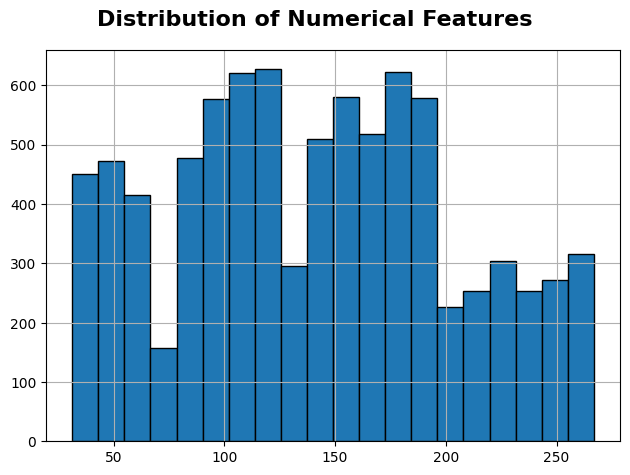

In [ ]:
plot_df = df.copy()
plt.figure()
plot_df['Item_MRP'].hist(
    bins=20,
    edgecolor='black', )
# plot_df[['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']].hist(
#     bins=10,
#     edgecolor='black', )
plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# BOXPLOTS - Statistical Summaries of Numerical Features

/tmp/ipykernel_1090/1340695625.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(df['Item_Weight'].dropna(), vert=True, patch_artist=True, labels=['Item Weight'])
/tmp/ipykernel_1090/1340695625.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(df['Item_Visibility'], vert=True, patch_artist=True, labels=['Item Visibility'])
/tmp/ipykernel_1090/1340695625.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 2].boxplot(df['Item_MRP'], vert=True, patch_artist=True, labels=['Item MRP'])
/tmp/ipykernel_1090/1340695625.py:20: MatplotlibDeprecationWarning: The 'labels' parame

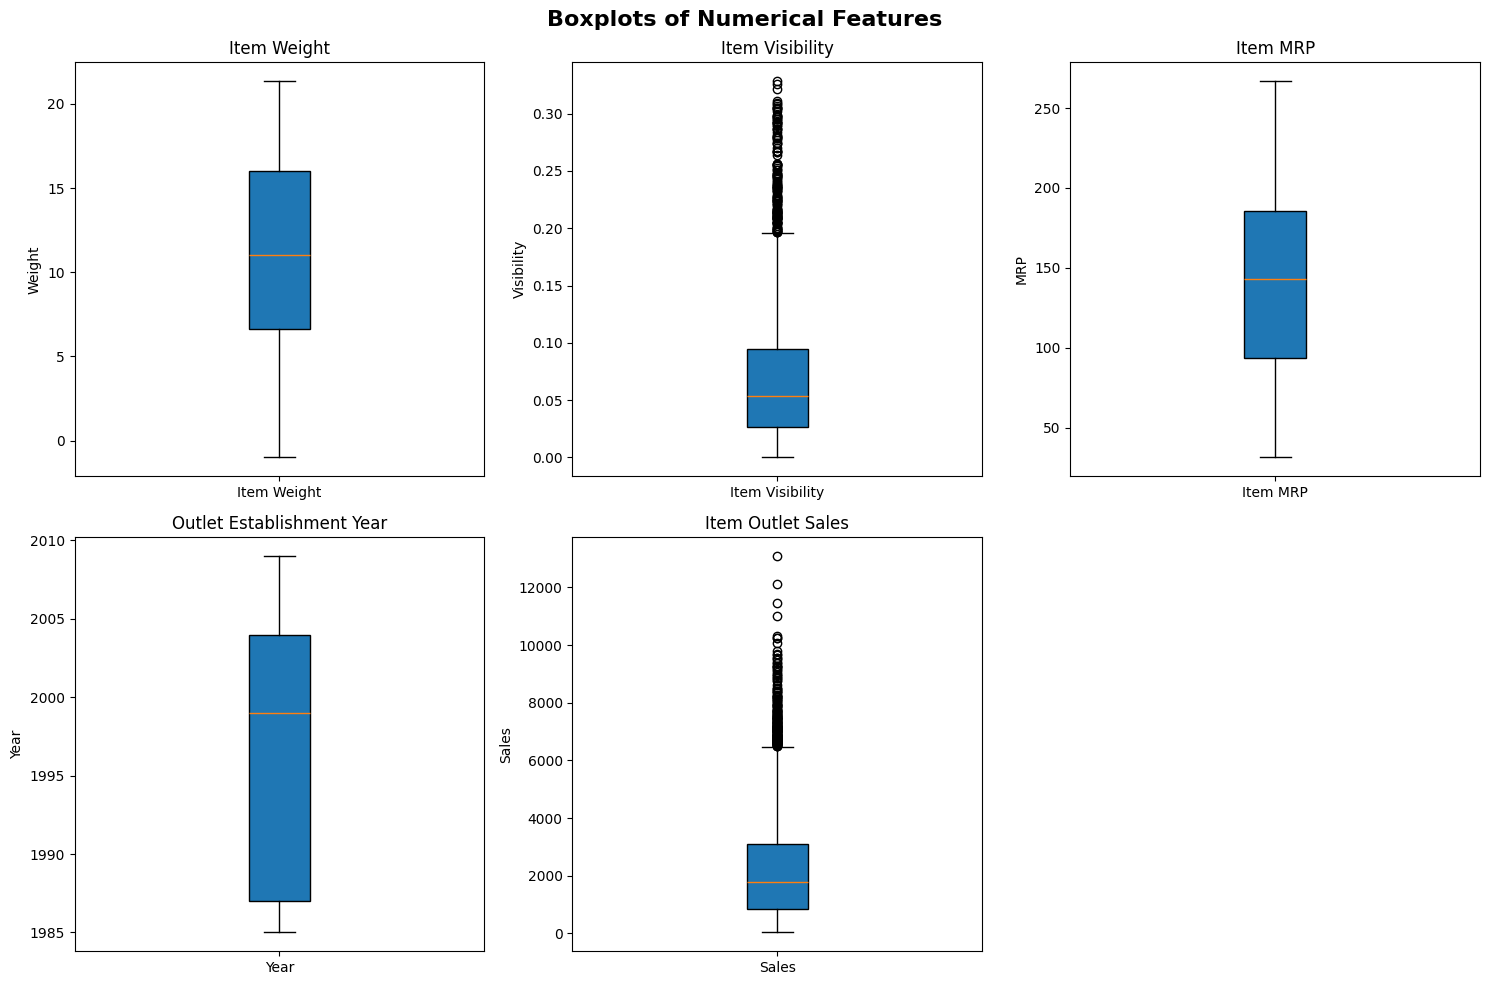

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Boxplots of Numerical Features', fontsize=16, fontweight='bold')

# Item_Weight
axes[0, 0].boxplot(df['Item_Weight'].dropna(), vert=True, patch_artist=True, labels=['Item Weight'])
axes[0, 0].set_title('Item Weight')
axes[0, 0].set_ylabel('Weight')

# Item_Visibility
axes[0, 1].boxplot(df['Item_Visibility'], vert=True, patch_artist=True, labels=['Item Visibility'])
axes[0, 1].set_title('Item Visibility')
axes[0, 1].set_ylabel('Visibility')


axes[0, 2].boxplot(df['Item_MRP'], vert=True, patch_artist=True, labels=['Item MRP'])
axes[0, 2].set_title('Item MRP')
axes[0, 2].set_ylabel('MRP')

# Outlet_Establishment_Year
axes[1, 0].boxplot(df['Outlet_Establishment_Year'], vert=True, patch_artist=True, labels=['Year'])
axes[1, 0].set_title('Outlet Establishment Year')
axes[1, 0].set_ylabel('Year')

# Item_Outlet_Sales
axes[1, 1].boxplot(df['Item_Outlet_Sales'], vert=True, patch_artist=True, labels=['Sales'])
axes[1, 1].set_title('Item Outlet Sales')
axes[1, 1].set_ylabel('Sales')

# Hide the empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# COUNTPLOTS - Frequency of Categorical Features

/tmp/ipykernel_1090/3344852690.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Item_Fat_Content', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_1090/3344852690.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Item_Type', ax=axes[0, 1], palette='Set3', order=top_item_types)
/tmp/ipykernel_1090/3344852690.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outlet_Size', ax=axes[1, 0], palette='Set1')
/tmp/ipykernel_1090/3344852690.py:21: FutureWarning: 

Passing `palette` without assigning `hu

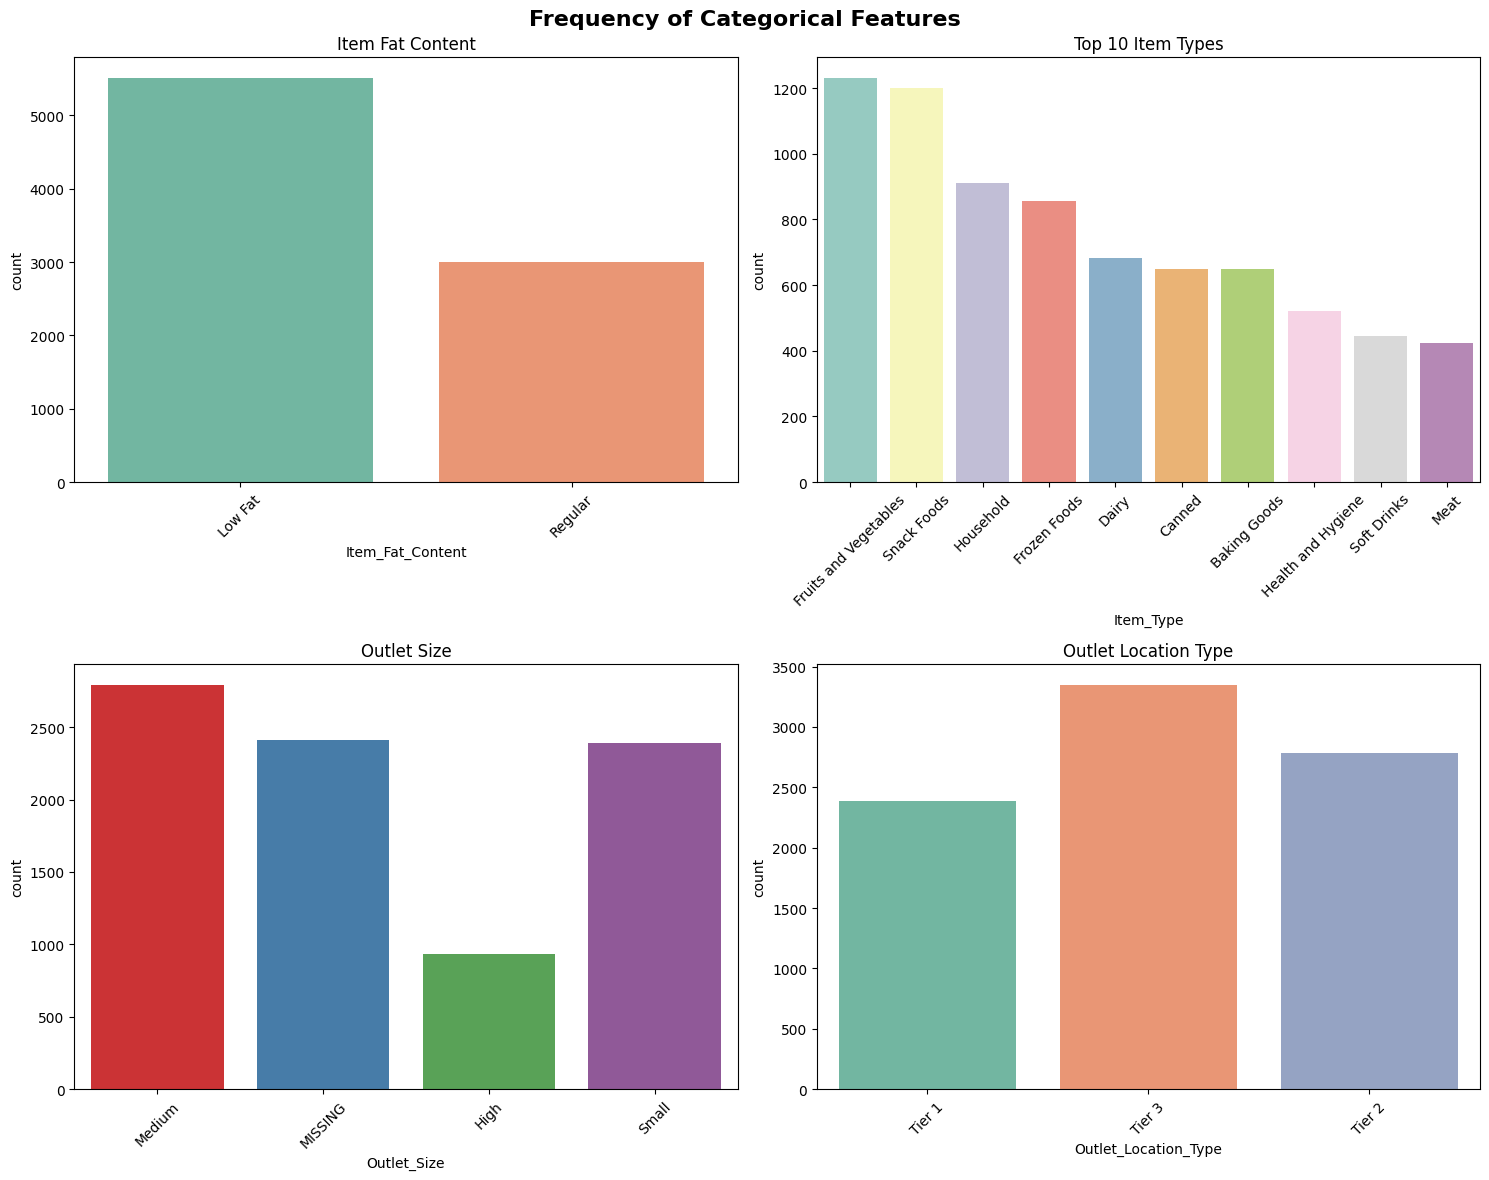

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Frequency of Categorical Features', fontsize=16, fontweight='bold')

# Item_Fat_Content
sns.countplot(data=df, x='Item_Fat_Content', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Item Fat Content')
axes[0, 0].tick_params(axis='x', rotation=45)

# Item_Type (Top 10 only to avoid clutter)
top_item_types = df['Item_Type'].value_counts().nlargest(10).index
sns.countplot(data=df, x='Item_Type', ax=axes[0, 1], palette='Set3', order=top_item_types)
axes[0, 1].set_title('Top 10 Item Types')
axes[0, 1].tick_params(axis='x', rotation=45)

# Outlet_Size
sns.countplot(data=df, x='Outlet_Size', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Outlet Size')
axes[1, 0].tick_params(axis='x', rotation=45)

# Outlet_Location_Type
sns.countplot(data=df, x='Outlet_Location_Type', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Outlet Location Type')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

 # HEATMAP - Correlation between Features

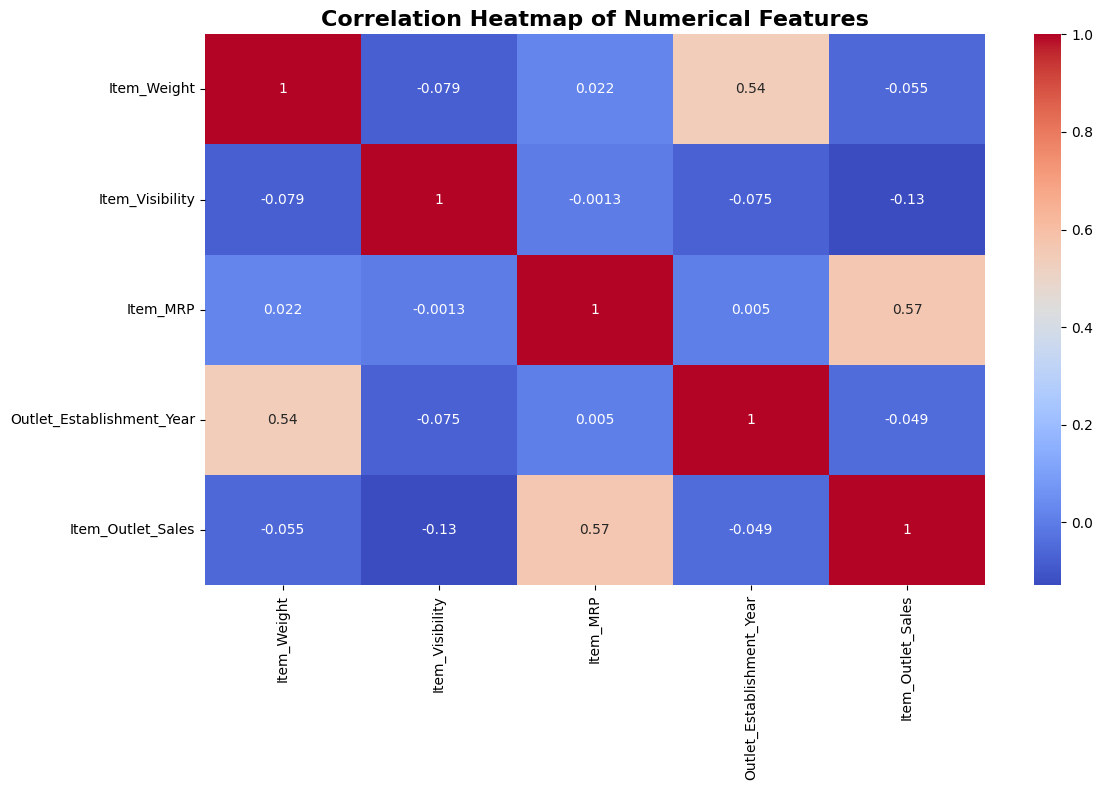

In [ ]:
plt.figure(figsize=(12, 8))
# Select only numerical columns for correlation
numerical_df = df[['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']]
correlation_matrix = numerical_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Replace the Palceholders back with null value

In [ ]:

# For numeric columns (Item_Weight was filled with -1)
df['Item_Weight'] = df['Item_Weight'].replace(-1, np.nan)

In [ ]:
# For categorical columns (Outlet_Size was filled with 'MISSING')
df['Outlet_Size'] = df['Outlet_Size'].replace('MISSING', np.nan)

In [ ]:
# verify the null vaules in the dataset
print("Null values in the Dataset")
print(df.isnull().sum())

Null values in the Dataset
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


# Data Dictionary


| Variable Name | Description |
| :--- | :--- |
| **Item_Identifier** | Product ID |
| **Item_Weight** | Weight of product |
| **Item_Fat_Content** | Whether the product is low-fat or regular |
| **Item_Visibility** | The percentage of total display area of all products in a store allocated to the particular product |
| **Item_Type** | The category to which the product belongs |
| **Item_MRP** | Maximum Retail Price (list price) of the product |
| **Outlet_Identifier** | Store ID |
| **Outlet_Establishment_Year** | The year in which store was established |
| **Outlet_Size** | The size of the store in terms of ground area covered |
| **Outlet_Location_Type** | The type of area in which the store is located |
| **Outlet_Type** | Whether the outlet is a grocery store or some sort of supermarket |
| **Item_Outlet_Sales** | Sales of the product in the particular store. This is the target variable to be predicted. |

# Feature 1: Item_Identifier

- Definition: Unique product ID assigned to each item. It is a categorical variable with many levels.



- **Univariate Visualization:**



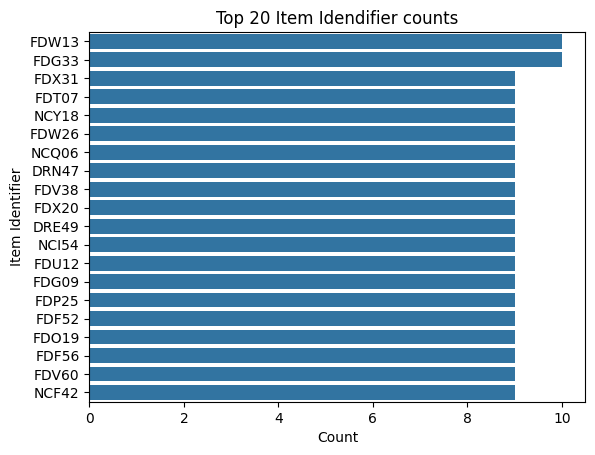

In [ ]:
plt.figure()
item_counts = df['Item_Identifier'].value_counts().head(20)
sns.barplot(x=item_counts.values , y = item_counts.index)
plt.title("Top 20 Item Idendifier counts")
plt.xlabel("Count")
plt.ylabel("Item Identifier")
plt.show()

In [ ]:
# For Item_Identifier:
col = 'Item_Identifier'
n_unique = df[col].nunique()

print(f"Constant/Quasi-constant: {'Yes' if n_unique == 1 or df[col].value_counts(normalize=True).iloc[0] > 0.95 else 'No'} - Has {n_unique} unique values")
print(f"Cardinality: {'High' if n_unique > 10 else 'Low'} ({n_unique} unique values {'>' if n_unique > 10 else '<='} 10)")

Constant/Quasi-constant: No - Has 1559 unique values
Cardinality: High (1559 unique values > 10)


**Feature Inspection Answers:**

- Type: Categorical (nominal) -  It's a unique identifier with no inherent order

- Null values: None (0%). No action needed.

- Constant/quasi-constant? No, many different values.

- Cardinality: 1559 unique values (>10, high cardinality).

- Known before target? Yes, Product ID is assigned before sales

- Business case to exclude? yes , Should be excluded from modeling as it's just an identifier with no predictive value.



- **Multivariate Visualization vs Target:**



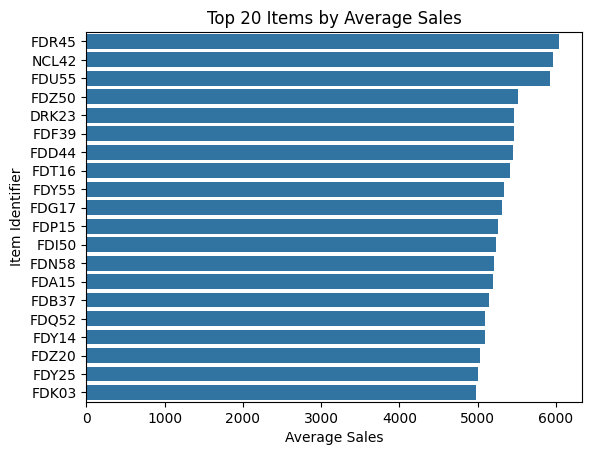

In [ ]:
plt.figure()
Item_sales = df.groupby('Item_Identifier')['Item_Outlet_Sales'].mean().sort_values(ascending=False).head(20)
sns.barplot(x = Item_sales.values , y = Item_sales.index)
plt.title("Top 20 Items by Average Sales")
plt.xlabel("Average Sales")
plt.ylabel("Item Identifier")
plt.show()

**Predictor Analysis:**

- Expected to be a predictor: No - It's just an ID

- Appears to be a predictor: No - Should be dropped from the model


## Feature2: Item_Weight

- Definition: Weight of the product . Numeric continuous variable.



**Univariate Visualization**


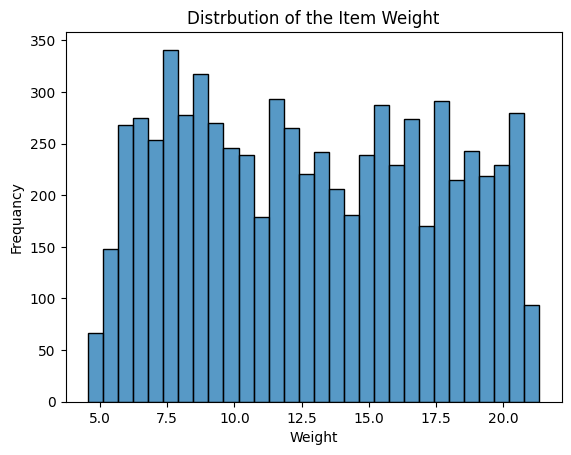

In [ ]:
plt.figure()
sns.histplot(df['Item_Weight'], bins = 30)
plt.title("Distrbution of the Item Weight")
plt.xlabel("Weight")
plt.ylabel("Frequancy")
plt.show()

**Feature Inspection Answers:**
- Type of feature: Numeric (Continuous)

- Null values: 1463 null values (~17.17%)

- Action: Impute with median or mean (median is better for skewed data)

- Constant/Quasi-constant: No - Range from 4.56 to 21.35

- Cardinality: Not applicable (numeric feature)

- Known before target: Yes - Product weight is known before sale

- Business reason to exclude: No - Weight could affect shipping, handling, and customer preferences


**Multivariate Visualization**


<Axes: xlabel='Item_Weight', ylabel='Item_Outlet_Sales'>

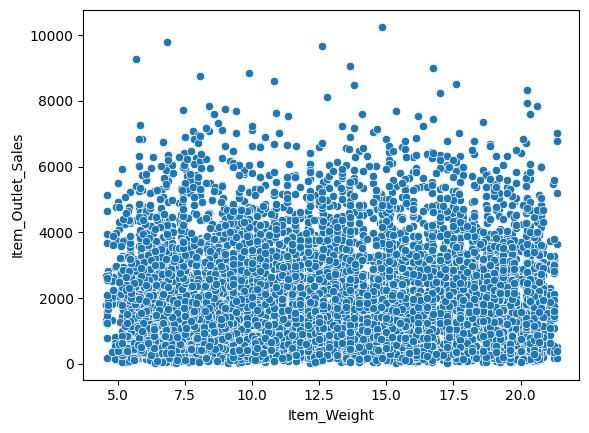

In [ ]:
plt.figure()
sns.scatterplot(data = df , x = 'Item_Weight' , y = 'Item_Outlet_Sales')

**Predictor Analysis:**

- Expected to be a predictor: Possibly - Heavier items might have different sales patterns

- Appears to be a predictor: Weak predictor - Shows some variation but not strong correlation


## Feature 3: Item_Fat_Content
- Definition: Indicates whether the product is low fat or regular. Categorical nominal (but we have only two categories after cleaning: Low Fat and Regular).



**Univariate Visualization**


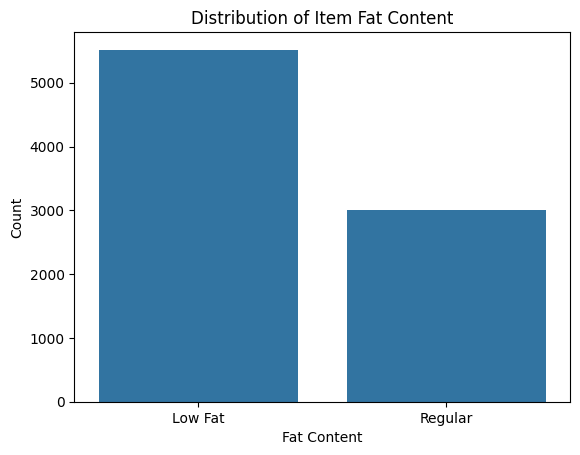

In [ ]:
plt.figure()
sns.countplot(data =df , x ="Item_Fat_Content")
plt.title('Distribution of Item Fat Content')
plt.xlabel('Fat Content')
plt.ylabel('Count')
plt.show()


**Feature Inspection Answers:**

- Type of feature: Categorical (Nominal)

- Null values: 0 null values (0%)

- Constant/Quasi-constant: No - Has two categories with ~5517 Low Fat, ~3006 Regular.



- Cardinality: Low (2 unique values < 10)

- Known before target: Yes - Fat content is a product attribute

- Business reason to exclude: No - Health-conscious consumers might prefer low-fat options

**Multivariate Visualization**


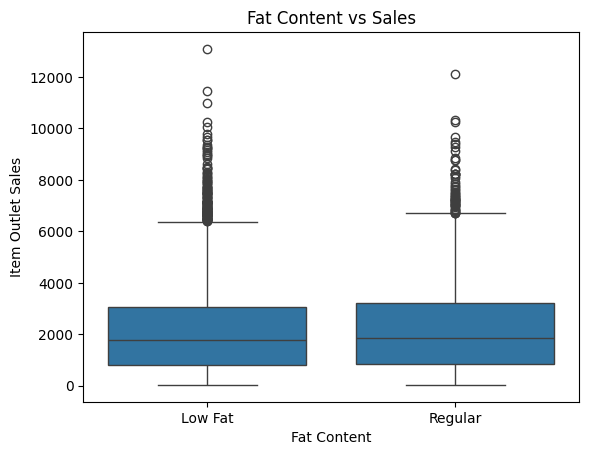

In [ ]:
plt.figure()
sns.boxplot(data = df , x='Item_Fat_Content', y='Item_Outlet_Sales')
plt.title('Fat Content vs Sales')
plt.xlabel('Fat Content')
plt.ylabel('Item Outlet Sales')
plt.show()


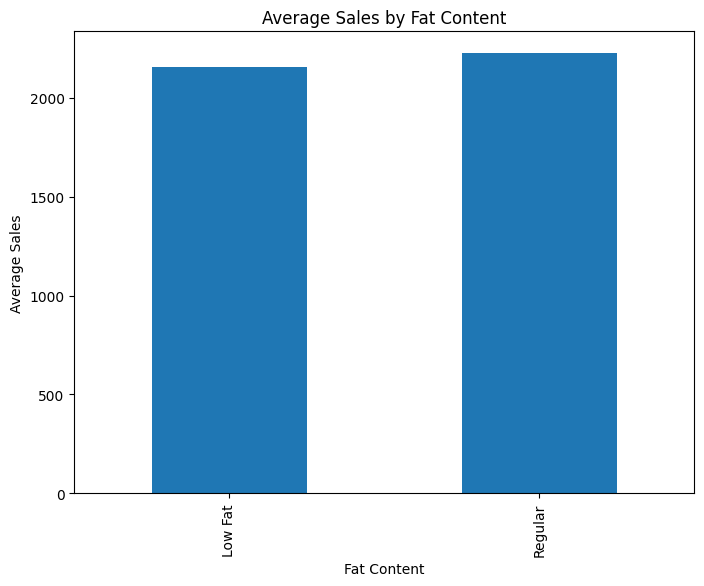

In [ ]:
plt.figure(figsize=(8, 6))
df.groupby('Item_Fat_Content')['Item_Outlet_Sales'].mean().plot(kind='bar')
plt.title('Average Sales by Fat Content')
plt.xlabel('Fat Content')
plt.ylabel('Average Sales')
plt.show()

**Predictor Analysis:**

- Expected to be a predictor: Yes - Consumer preferences for healthy options

- Appears to be a predictor: Moderate - Different fat content shows different sales distributions


# Feature 4: Item_Visibility
 - Definition: The percentage of total display area allocated to the product in the store. Numeric continuous.



**Univariate Visualization**


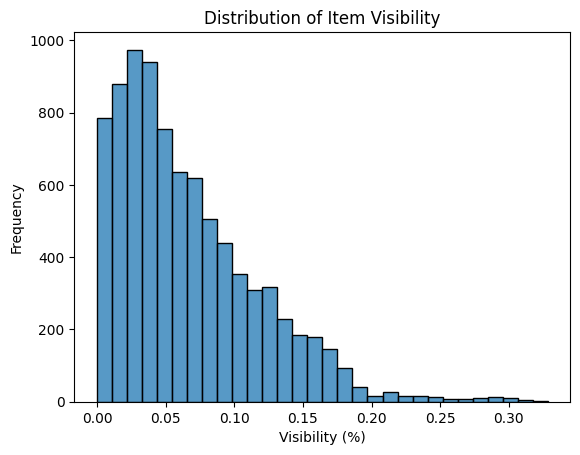

In [ ]:
plt.figure()
sns.histplot(df['Item_Visibility'], bins = 30)
plt.title("Distribution of Item Visibility")
plt.xlabel("Visibility (%)")
plt.ylabel("Frequency")
plt.show()

**Feature Inspection Answers:**
- Type of feature: Numeric (Continuous)

- Null values: 0 null values (0%)

- Constant/Quasi-constant: No - Range from 0 to 0.33 (0-33%)

- Cardinality: Not applicable (numeric feature)

- Known before target: Yes - Visibility is set before sales occur

- Business reason to exclude: No - Product placement affects visibility and sales


**Multivariate Visualization**


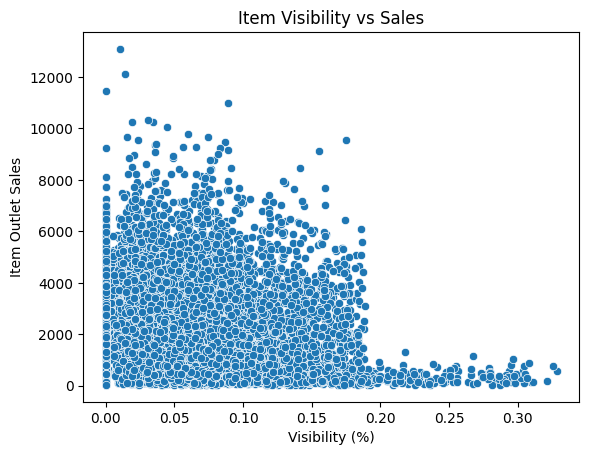

In [ ]:
plt.figure()
sns.scatterplot(data= df, x='Item_Visibility', y='Item_Outlet_Sales')
plt.title('Item Visibility vs Sales')
plt.xlabel('Visibility (%)')
plt.ylabel('Item Outlet Sales')
plt.show()

**Predictor Analysis:**
- Expected to be a predictor: Yes - More visible products typically sell more

- Appears to be a predictor: Yes - Shows positive correlation with sales


#Feature 5: Item_Type

Category of the product (e.g., Dairy, Snack Foods, Fruits and Vegetables, Household, etc.). There are 16 different product categories

**Univariate Visualization**


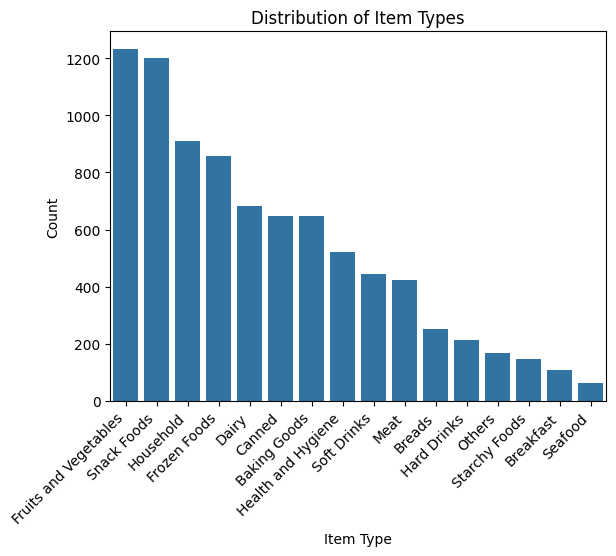

In [ ]:
plt.figure()
sns.countplot(data= df, x= 'Item_Type',order=df['Item_Type'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Item Types')
plt.xlabel('Item Type')
plt.ylabel('Count')
plt.show()


**Feature Inspection Answers:**

- Type of feature: Categorical (Nominal)

- Null values: 0 null values (0%)

- Constant/Quasi-constant: No - Has 16 categories

- Cardinality: High (16 unique values > 10)

- Known before target: Yes - Product category is fixed

- Business reason to exclude: No - Different categories have different demand patterns


**Multivariate Visualization**


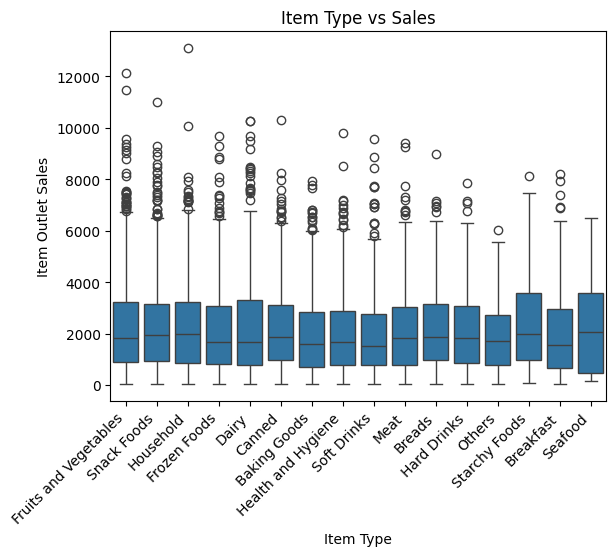

In [ ]:
plt.figure()
sns.boxplot(data=df, x='Item_Type', y='Item_Outlet_Sales', order=df['Item_Type'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Item Type vs Sales')
plt.xlabel('Item Type')
plt.ylabel('Item Outlet Sales')
plt.show()

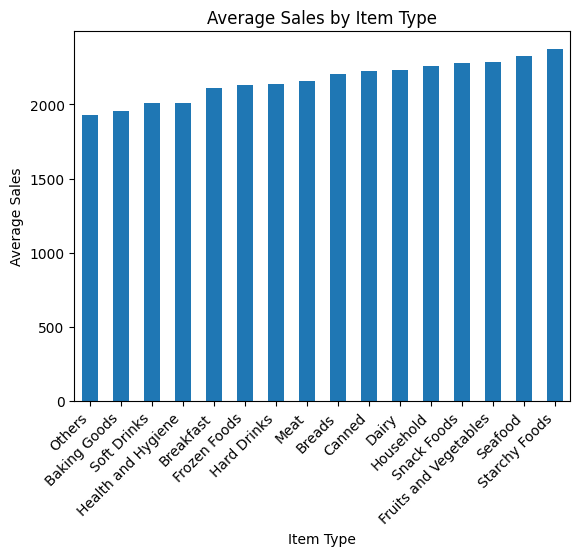

In [ ]:
plt.figure()
df.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values().plot(kind='bar')
plt.title('Average Sales by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Average Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

**Predictor Analysis:**

- Expected to be a predictor: Yes - Different product categories have different sales volumes

- Appears to be a predictor: yes - Boxplot shows varying medians; e.g., Seafood has lower sales, Fruits and Vegetables have wide spread. So likely predictive


# Feature 6: Item_MRP

- Definition: Maximum Retail Price of the product. This is the listed price at which the product is sold.


**Univariate Visualization**

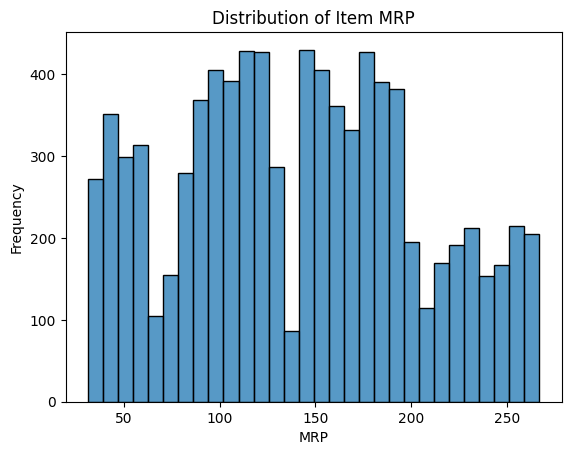

In [ ]:
plt.figure()
sns.histplot(df['Item_MRP'], bins = 30)
plt.title('Distribution of Item MRP')
plt.xlabel('MRP')
plt.ylabel('Frequency')
plt.show()

**Feature Inspection Answers:**

- Type of feature: Numeric (Continuous)

- Null values: 0 null values (0%)

- Constant/Quasi-constant: No - Range from 31.29 to 266.89

- Cardinality: Not applicable (numeric feature)

- Known before target: Yes - Price is set before sale

- Business reason to exclude: No - Price is a critical factor in sales

**Multivariate Visualization**

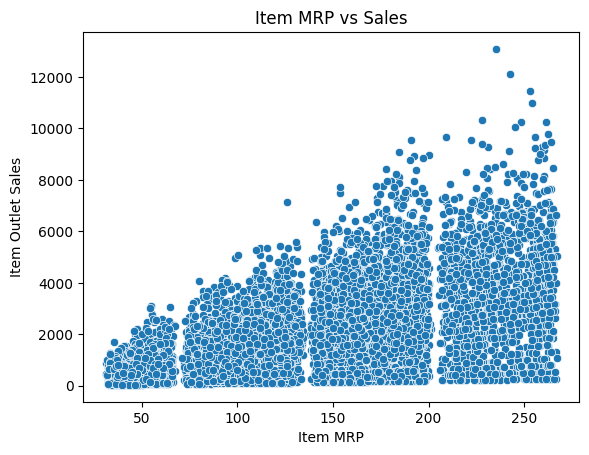

In [ ]:
plt.figure()
sns.scatterplot(data= df, x= 'Item_MRP', y='Item_Outlet_Sales')
plt.title("Item MRP vs Sales")
plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")
plt.show()

**Predictor Analysis:**

- Expected to be a predictor: Yes - Price directly affects sales

- Appears to be a predictor: Yes - Strong positive correlation with sales (one of the strongest predictors)


# Feature 7: Outlet_Identifier
Unique store ID. Categorical nominal with 10 outlets

**Univariate Visualization**


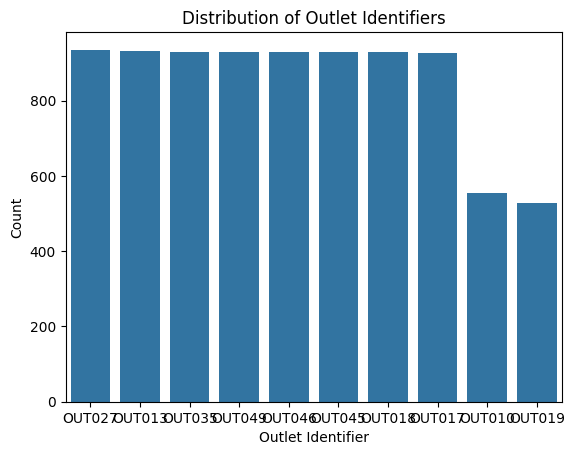

In [ ]:
plt.figure()
sns.countplot(data= df, x = 'Outlet_Identifier', order=df['Outlet_Identifier'].value_counts().index)
plt.title("Distribution of Outlet Identifiers")
plt.xlabel("Outlet Identifier")
plt.ylabel("Count")
plt.show()


**Feature Inspection Answers:**

- Type of feature: Categorical (Nominal)

- Null values: 0 null values (0%)

- Constant/Quasi-constant: No - Has 10 unique outlets

- Cardinality: Moderate (10 unique values)

- Known before target: Yes - Store location is known

- Business reason to exclude: CONSIDER - Could be excluded or kept depending on whether we want store-specific predictions


**Multivariate Visualization**

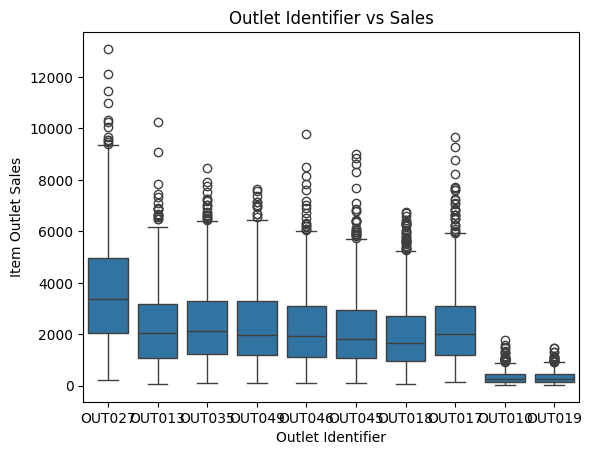

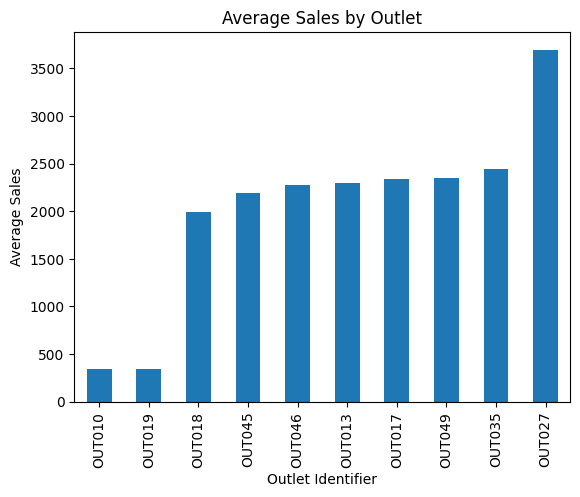

In [ ]:
plt.figure()
sns.boxplot(data= df, x='Outlet_Identifier', y='Item_Outlet_Sales', order=df['Outlet_Identifier'].value_counts().index)
plt.title('Outlet Identifier vs Sales')
plt.xlabel('Outlet Identifier')
plt.ylabel('Item Outlet Sales')
plt.show()

plt.figure()
df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].mean().sort_values().plot(kind='bar')
plt.title('Average Sales by Outlet')
plt.xlabel('Outlet Identifier')
plt.ylabel('Average Sales')
plt.show()

**Predictor Analysis:**

- Expected to be a predictor: Yes - Different stores have different customer bases
- Appears to be a predictor: Yes - Shows variation in sales across outlets


# Feature 8: Outlet_Establishment_Year
- Year when the store/outlet was established. This indicates the age of the outlet.

**Univariate Visualization**

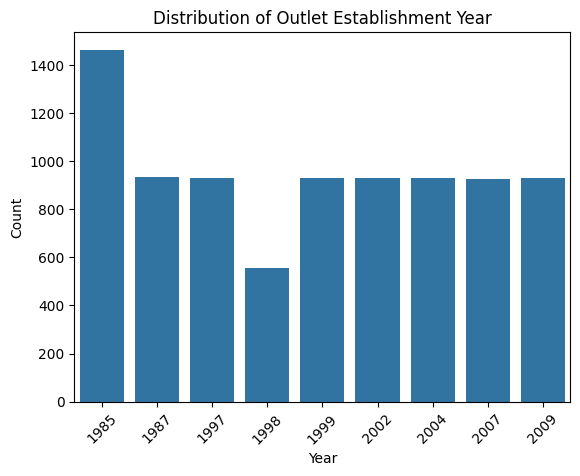

In [ ]:
plt.figure()
sns.countplot(data=df, x='Outlet_Establishment_Year')
plt.xticks(rotation=45)
plt.title('Distribution of Outlet Establishment Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

**Feature Inspection Answers:**

- Type of feature: Numeric (Discrete/Ordinal)

- Null values: 0 null values (0%)

- Constant/Quasi-constant: No - Range from 1985 to 2009

- Cardinality: Not applicable (numeric feature)

- Known before target: Yes - Store age is known

- Business reason to exclude: No - Older stores might have established customer bases

**Multivariate Visualization**

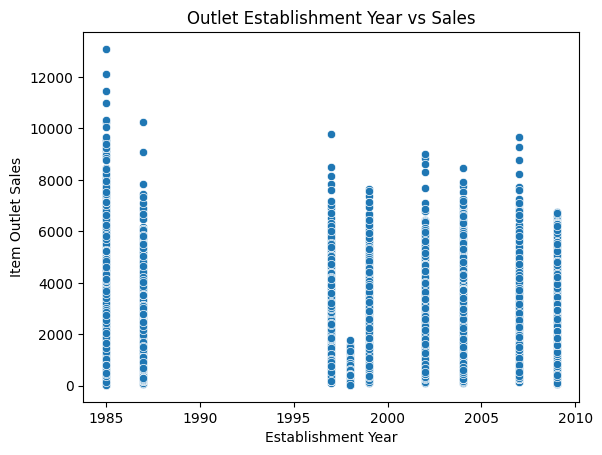

In [ ]:
plt.figure()
sns.scatterplot(data= df, x ="Outlet_Establishment_Year", y ="Item_Outlet_Sales")
plt.title('Outlet Establishment Year vs Sales')
plt.xlabel('Establishment Year')
plt.ylabel('Item Outlet Sales')
plt.show()

**Predictor Analysis:**

- Expected to be a predictor: Possibly - Store age might affect customer loyalty

- Appears to be a predictor: Weak - Shows some variation but not strong


# Feature 9: Outlet_Size
Size of the store categorized as Small, Medium, or High/Large. This indicates the physical size of the outlet.

**Univariate Visualization**

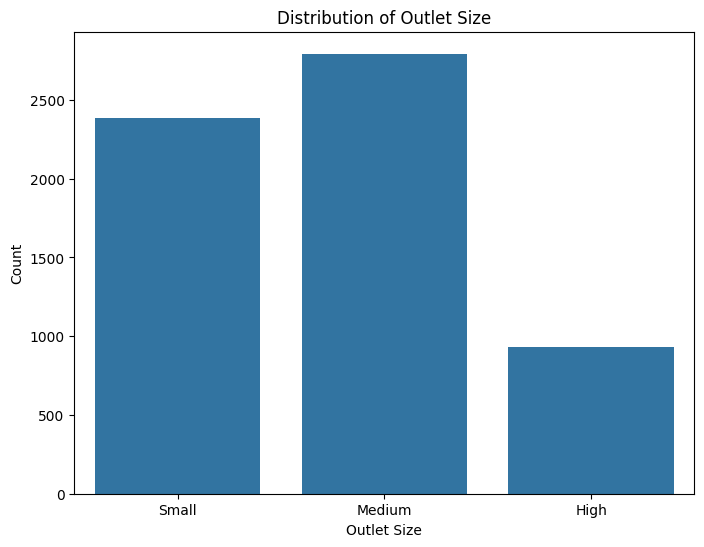

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data= df ,x='Outlet_Size', order= ['Small', 'Medium', 'High'])
plt.title('Distribution of Outlet Size')
plt.xlabel('Outlet Size')
plt.ylabel('Count')
plt.show()


**Feature Inspection Answers:**

- Type of feature: Categorical (Ordinal) - Small < Medium < High

- Null values: 2410 null values (~28.28%)

- Action: Impute with mode or based on Outlet_Type relationship

- Constant/Quasi-constant: No - Has 3 categories

- Cardinality: Low (3 unique values < 10)

- Known before target: Yes - Store size is fixed

- Business reason to exclude: No - Store size affects product range and sales


**Multivariate Visualization**

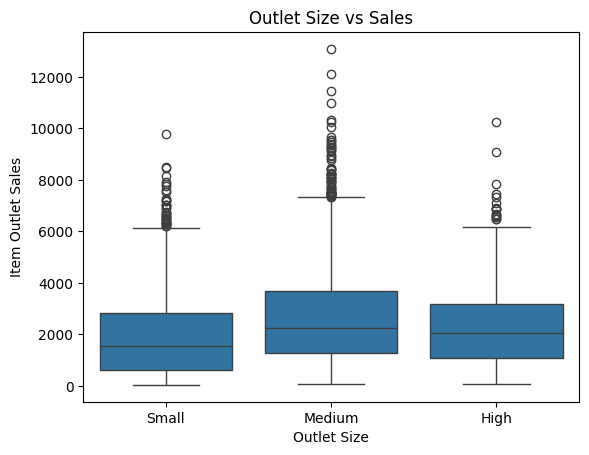

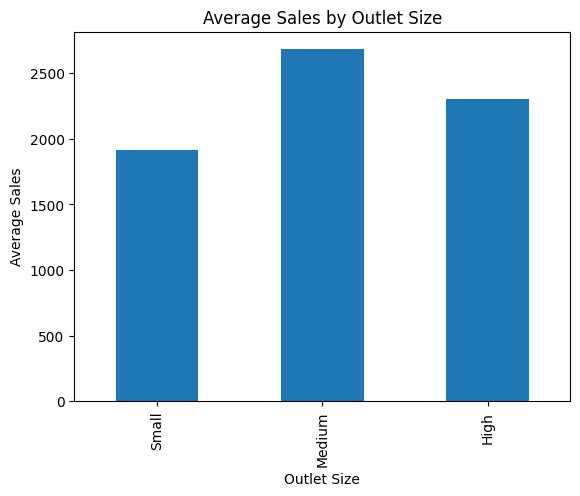

In [ ]:
plt.figure()
sns.boxplot(data=df, x='Outlet_Size', y='Item_Outlet_Sales', order=['Small', 'Medium', 'High'])
plt.title('Outlet Size vs Sales')
plt.xlabel('Outlet Size')
plt.ylabel('Item Outlet Sales')
plt.show()

plt.figure()
df.groupby('Outlet_Size')['Item_Outlet_Sales'].mean().reindex(['Small', 'Medium', 'High']).plot(kind='bar')
plt.title('Average Sales by Outlet Size')
plt.xlabel('Outlet Size')
plt.ylabel('Average Sales')
plt.show()

**Predictor Analysis:**

- Expected to be a predictor: Yes - Larger stores typically have more sales

- Appears to be a predictor: Yes - Different sizes show different sales patterns


# Feature 10: Outlet_Location_Type

Type of location where the store is situated, categorized as Tier 1, Tier 2, or Tier 3. This indicates the city tier/development level.

**Univariate Visualization**

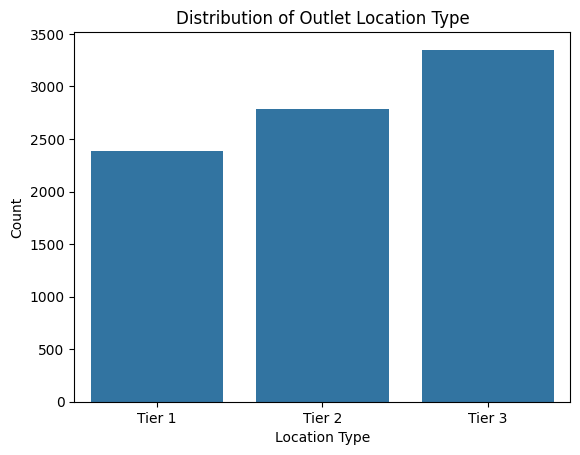

In [ ]:
plt.figure()
sns.countplot(data= df, x = "Outlet_Location_Type", order=['Tier 1', 'Tier 2', 'Tier 3'])
plt.title("Distribution of Outlet Location Type")
plt.xlabel("Location Type")
plt.ylabel("Count")
plt.show()

**Feature Inspection Answers:**

- Type of feature: Categorical (Ordinal) - Tier 1 < Tier 2 < Tier 3

- Null values: 0 null values (0%)

- Constant/Quasi-constant: No - Has 3 categories

- Cardinality: Low (3 unique values < 10)

- Known before target: Yes - Location is fixed

- Business reason to exclude: No - Location affects demographics and purchasing power


**Multivariate Visualization**

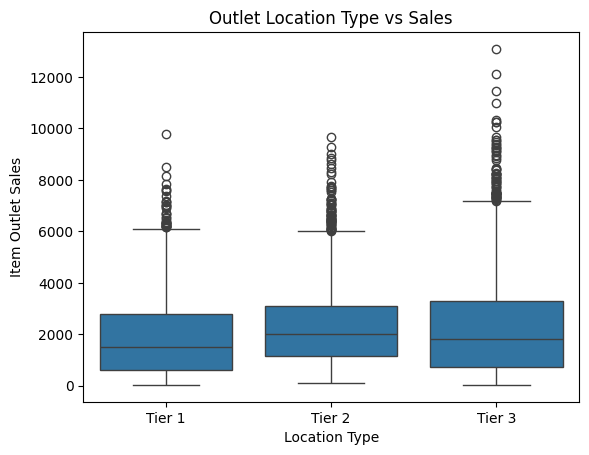

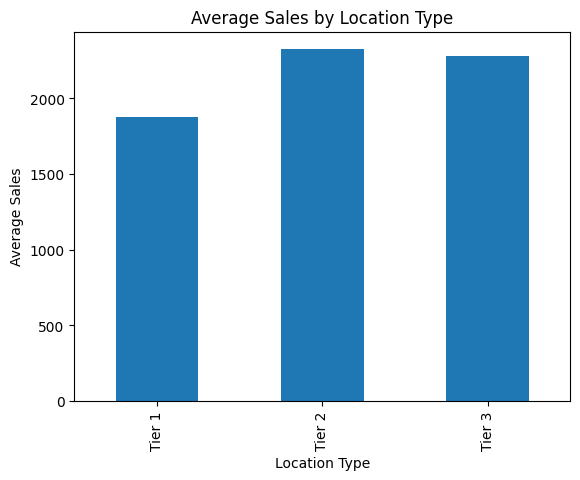

In [ ]:
plt.figure()
sns.boxplot(data=df, x='Outlet_Location_Type', y='Item_Outlet_Sales', order=['Tier 1', 'Tier 2', 'Tier 3'])
plt.title('Outlet Location Type vs Sales')
plt.xlabel('Location Type')
plt.ylabel('Item Outlet Sales')
plt.show()

plt.figure()
df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].mean().reindex(['Tier 1', 'Tier 2', 'Tier 3']).plot(kind='bar')
plt.title('Average Sales by Location Type')
plt.xlabel('Location Type')
plt.ylabel('Average Sales')
plt.show()

**Predictor Analysis:**

- Expected to be a predictor: Yes - Different tiers have different income levels
- Appears to be a predictor: Yes - Shows variation across tiers


# Feature 11: Outlet_Type
Type of store - Grocery Store, Supermarket Type 1, Type 2, or Type 3. This indicates the format and size of the retail outlet

**Univariate Visualization**

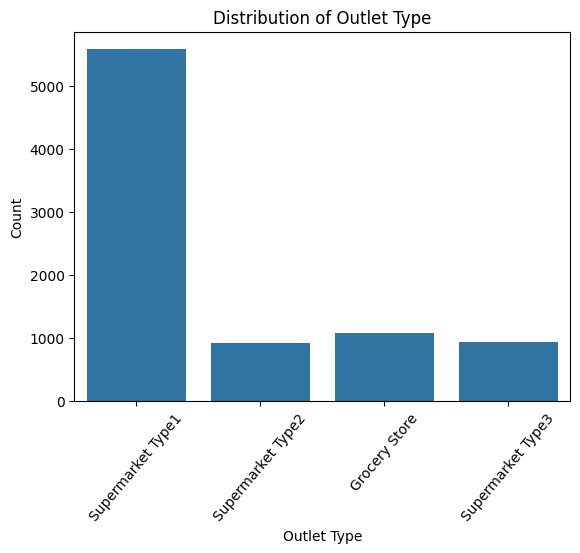

In [ ]:
plt.figure()
sns.countplot(data= df, x = "Outlet_Type")
plt.xticks(rotation = 50)
plt.title('Distribution of Outlet Type')
plt.xlabel('Outlet Type')
plt.ylabel('Count')
plt.show()

**Feature Inspection Answers:**
- Type of feature: Categorical (Nominal)
- Null values: 0 null values (0%)
- Constant/Quasi-constant: No - Has 4 categories
- Cardinality: Low (4 unique values < 10)
- Known before target: Yes - Store type is fixed
- Business reason to exclude: No - Different store types serve different markets


**Multivariate Visualization**

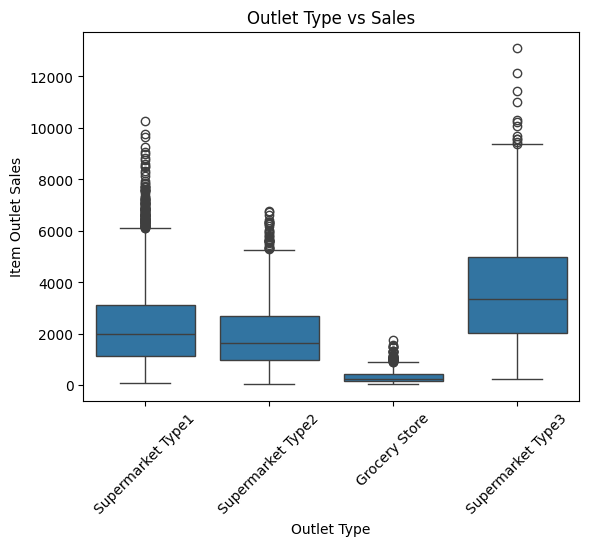

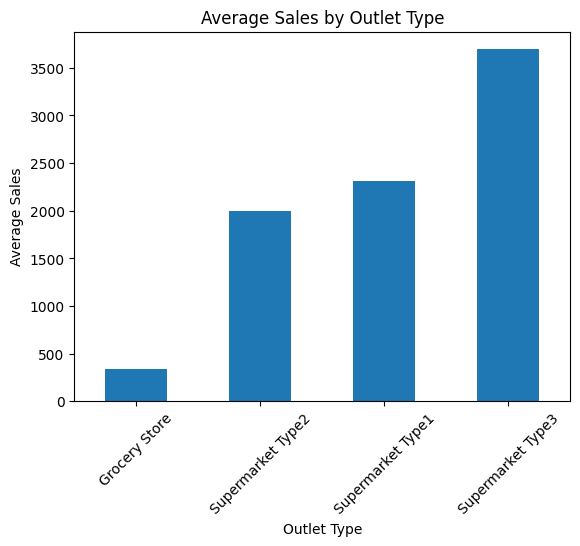

In [ ]:
plt.figure()
sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales')
plt.xticks(rotation=45)
plt.title('Outlet Type vs Sales')
plt.xlabel('Outlet Type')
plt.ylabel('Item Outlet Sales')
plt.show()

plt.figure()
df.groupby('Outlet_Type')['Item_Outlet_Sales'].mean().sort_values().plot(kind='bar')
plt.title('Average Sales by Outlet Type')
plt.xlabel('Outlet Type')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.show()

**Predictor Analysis:**
- Expected to be a predictor: Yes, supermarkets likely sell more than grocery stores. different sales
- Appears to be a predictor: Yes - Boxplot shows clear differences: Grocery Store has lower sales, Supermarket Type1 higher. Strong predictor.


# Summary of Key Findings:

**Features to Drop:**
1. Item_Identifier - Just an ID, no predictive value
2. Outlet_Identifier - Consider dropping or keeping based on model goals

---
**Features Needing Imputation:**
- Item_Weight - 17.17% missing → Impute with median
- Outlet_Size - 28.28% missing → Impute with mode or based on Outlet_Type
---

**Strongest Predictors (based on business understanding):**

- Item_MRP - Price directly affects sales
- Outlet_Type - Store format affects sales volume
- Item_Type - Product category affects demand
- Item_Visibility - Product placement affects sales
---
**Moderate Predictors:**
- Item_Fat_Content - Consumer preferences
- Outlet_Location_Type - Demographics
- Outlet_Size - Store capacity